<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


I0000 00:00:1790790656.554098    9818 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Datos

Igual que en el desafio anterior, el corpus seleccionado es la metamorfosis de Franz Kafka.

In [2]:
# Ruta al archivo de texto local
file_path = "metamorfosis.txt"

# Leer el contenido del archivo
with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

# Texto completo en minúsculas
article_text = raw_text.lower()


In [3]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

'cuando gregorio samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto. estaba tumbado sobre su espalda dura, y en forma de caparazón y, al levantar un poco la cabeza veía un vientre abombado, parduzco, dividido por partes duras en forma de arco, sobre cuya protuberancia apenas podía mantenerse el cobertor, a punto ya de resbalar al suelo. sus muchas patas, ridículamente pequeñas en comparación con el resto de su tamaño, le vibraban desamparadas ante los ojos.\n\n«¿qué me ha ocurrido?», pensó.\n\nno era un sueño. su habitación, una auténtica habitación humana, si bien algo pequeña, permanecía tranquila entre las cuatro paredes harto conocidas. por encima de la mesa, sobre la que se encontraba extendido un muestrario de paños desempaquetados —samsa era viajante de comercio—, estaba colgado aquel cuadro que hacía poco había recortado de una revista y había colocado en un bonito marco dorado. representaba a una dama ata

### Elegir el tamaño del contexto

Para seleccionar el tamano de la ventana de contexto se propone ver la longitud de cada oracion del corpus

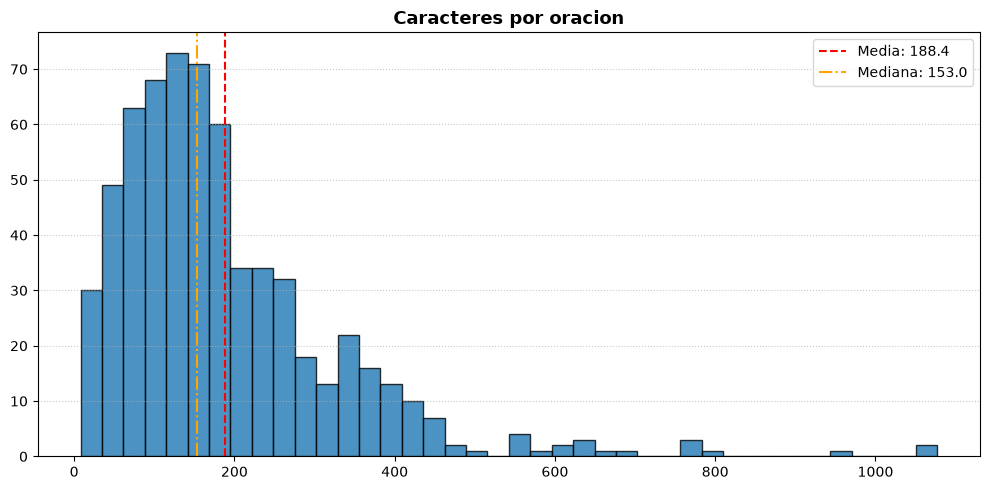

In [4]:
import re
import matplotlib.pyplot as plt
import numpy as np

if isinstance(article_text, list):
    full_text = " ".join(article_text)
else:
    full_text = article_text

raw_sentences = re.split(r'\.+', full_text)

sentences = [s.strip() for s in raw_sentences if s.strip()]
char_counts = [len(s) for s in sentences]
mean_len = np.mean(char_counts)
median_len = np.median(char_counts)
p95_len = np.percentile(char_counts, 95)

plt.figure(figsize=(10, 5))
plt.hist(char_counts, bins=40, color="#1f77b4", edgecolor="black", alpha=0.8)

plt.axvline(mean_len, color="red", linestyle="--", linewidth=1.5, label=f"Media: {mean_len:.1f}")
plt.axvline(median_len, color="orange", linestyle="-.", linewidth=1.5, label=f"Mediana: {median_len:.1f}")

plt.title("Caracteres por oracion", fontsize=13, weight="bold")
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()


Vemos que la media es de alrededor de 200 caractes, por lo tanto usamos este numero para la ventana de contexto.

In [5]:
# seleccionamos el tamaño de contexto
max_context_size = 200

In [6]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [7]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [8]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

47

In [9]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [10]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [11]:
tokenized_text[:1000]

[29,
 39,
 41,
 4,
 31,
 43,
 37,
 13,
 14,
 3,
 13,
 43,
 14,
 6,
 43,
 37,
 17,
 41,
 20,
 17,
 41,
 37,
 17,
 3,
 37,
 31,
 3,
 17,
 36,
 3,
 14,
 22,
 10,
 37,
 39,
 4,
 41,
 37,
 20,
 41,
 33,
 41,
 4,
 41,
 37,
 31,
 3,
 17,
 36,
 39,
 42,
 17,
 37,
 31,
 3,
 37,
 39,
 4,
 37,
 17,
 39,
 3,
 33,
 43,
 37,
 6,
 4,
 22,
 14,
 41,
 4,
 8,
 39,
 6,
 9,
 43,
 1,
 37,
 17,
 3,
 37,
 3,
 4,
 29,
 43,
 4,
 22,
 14,
 10,
 37,
 17,
 43,
 7,
 14,
 3,
 37,
 17,
 39,
 37,
 29,
 41,
 20,
 41,
 37,
 29,
 43,
 4,
 32,
 3,
 14,
 22,
 6,
 31,
 43,
 37,
 3,
 4,
 37,
 39,
 4,
 37,
 20,
 43,
 4,
 17,
 22,
 14,
 39,
 43,
 17,
 43,
 37,
 6,
 4,
 17,
 3,
 29,
 22,
 43,
 40,
 37,
 3,
 17,
 22,
 41,
 7,
 41,
 37,
 22,
 39,
 20,
 7,
 41,
 31,
 43,
 37,
 17,
 43,
 7,
 14,
 3,
 37,
 17,
 39,
 37,
 3,
 17,
 36,
 41,
 9,
 31,
 41,
 37,
 31,
 39,
 14,
 41,
 1,
 37,
 2,
 37,
 3,
 4,
 37,
 34,
 43,
 14,
 20,
 41,
 37,
 31,
 3,
 37,
 29,
 41,
 36,
 41,
 14,
 41,
 26,
 10,
 4,
 37,
 2,
 1,
 37,
 41,
 9,
 37,
 9,
 3

### Organizando y estructurando el dataset

In [12]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [13]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [14]:
# tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_val = [val_text[init*max_context_size : (init+1)*max_context_size] for init in range(num_val)]

In [15]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [16]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [17]:
X.shape

(108670, 200)

In [18]:
X[0,:10]

array([29, 39, 41,  4, 31, 43, 37, 13, 14,  3])

In [19]:
y[0,:10]

array([39, 41,  4, 31, 43, 37, 13, 14,  3, 13])

In [20]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [21]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

In [22]:
class PplCallback(keras.callbacks.Callback):
    '''
    Callback para calcular Perplejidad en validación al final de cada epoch
    e implementar Early Stopping y Model Checkpoint.
    '''
    def __init__(self, val_data, history_ppl=None, patience=5, model_name="my_model.keras", max_context_size=None):
        super().__init__()
        self.val_data = val_data
        
        # Guardamos la referencia de la lista (o creamos una nueva si es None)
        self.history_ppl = history_ppl if history_ppl is not None else []
        
        self.patience = patience
        self.patience_counter = 0
        self.min_score = np.inf
        self.model_name = model_name
        self.max_context_size = max_context_size

        self.target = []
        self.padded = []
        self.info = []
        count = 0

        # Preprocesar secuencias de validación
        for seq in self.val_data:
            len_seq = len(seq)
            if len_seq <= 1:
                continue

            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            n_subseq = len(subseq)  # Son exactamente len_seq - 1 elementos
            self.padded.append(pad_sequences(subseq, maxlen=self.max_context_size, padding='pre'))
            
            # Guardamos el rango exacto de índices para esta secuencia
            self.info.append((count, count + n_subseq))
            count += n_subseq

        if len(self.padded) > 0:
            self.padded = np.vstack(self.padded)
        else:
            self.padded = np.empty((0, self.max_context_size if self.max_context_size else 0))

    def on_epoch_end(self, epoch, logs=None):
        if len(self.padded) == 0:
            return

        batch_size = 128
        last_preds = []
        for i in range(0, len(self.padded), batch_size):
            batch = self.padded[i:i + batch_size]
            batch_pred = self.model(batch, training=False)
            last_preds.append(batch_pred[:, -1, :].numpy())

        predictions = np.concatenate(last_preds, axis=0)

        scores = []
        for start, end in self.info:
            probs = [predictions[idx_seq, idx_vocab] 
                     for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])]
            
            # Protección contra log(0)
            probs = np.clip(probs, 1e-12, 1.0)
            scores.append(np.exp(-np.sum(np.log(probs)) / (end - start)))

        current_score = np.mean(scores)
        
        # Modifica la lista pasada por referencia
        self.history_ppl.append(current_score)
        
        # Opcional: registrar en el objeto history de Keras
        if logs is not None:
            logs['val_ppl'] = current_score

        print(f'\n-> Perplejidad media en validación: {current_score:.4f}\n')

        # Early Stopping & Guardado del mejor modelo
        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.model_name)
            print(f"Mejor perplejidad alcanzada ({current_score:.4f}). Modelo guardado en '{self.model_name}'!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter >= self.patience:
                print(f"Early Stopping: sin mejora en {self.patience} epochs consecutivas.")
                self.model.stop_training = True


### Arquitectura

Para una comparación justa entre arquitecturas a nivel caracter, se tomó como base una **Red de Elman de 128 celdas** y 2 capas y se ajustó el número de celdas en GRU y LSTM para igualar la cantidad total de pesos.

Si bien la cantidad de caracteres no es prohibitiva para usar one hot encoding, se opto por los embeddings a los fines de obtener una representacion semantica de los mismos.


#### Estructura Comun
1. **`Embedding(47, 16)`**: Proyecta los 47 caracteres a vectores continuos de 16 dimensiones.
2. **Capa Recurrente 1 (`return_sequences=True`, `dropout=0.2`)**
3. **Capa Recurrente 2 (`return_sequences=True`, `dropout=0.2`)**
4. **`Dense(47, activation='softmax')`**: Distribución de probabilidad para predecir el siguiente caracter.

#### Cantidad de Parametros

| Arquitectura | Celdas | Parámetros |
| :--- | :---: | :---: |
| **Elman** | **128** | **58.271** |
| **GRU** | **74** | **58.001** | 
| **LSTM** | **64** | **57.567** |

---

La idea es ver que modelo muestra mejor comportamiento para una cantidad de parametros dada

### Entrenamiento

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

VOCAB_SIZE = vocab_size      # Cantidad de caracteres
EMBEDDING_DIM = 16     # Dimension del embedding para caracteres
DROPOUT_RATE = 0.2     # Regularizacion

# Numero de unidades 
HIDDEN_ELMAN = 128
HIDDEN_GRU   = 74
HIDDEN_LSTM  = 64


def build_elman_rnn(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_size=HIDDEN_ELMAN):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(None,)),
        SimpleRNN(hidden_size, return_sequences=True, dropout=DROPOUT_RATE),
        SimpleRNN(hidden_size, return_sequences=True, dropout=DROPOUT_RATE),
        
        Dense(vocab_size, activation='softmax')
    ], name="Stacked_Elman_RNN")
    
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


def build_gru(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_size=HIDDEN_GRU):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(None,)),
        GRU(hidden_size, return_sequences=True, dropout=DROPOUT_RATE),
        GRU(hidden_size, return_sequences=True, dropout=DROPOUT_RATE),
        Dense(vocab_size, activation='softmax')
    ], name="Stacked_GRU")
    
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_size=HIDDEN_LSTM):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(None,)),
        LSTM(hidden_size, return_sequences=True, dropout=DROPOUT_RATE),
        LSTM(hidden_size, return_sequences=True, dropout=DROPOUT_RATE),
        Dense(vocab_size, activation='softmax')
    ], name="Stacked_LSTM")
    
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


elman_model = build_elman_rnn()
gru_model   = build_gru()
lstm_model  = build_lstm()

print(f"Elman params: {elman_model.count_params():,}")
print(f"GRU params:   {gru_model.count_params():,}")
print(f"LSTM params:  {lstm_model.count_params():,}")

elman_model.summary()
gru_model.summary()
lstm_model.summary()


/home/nacho/Documents/CEIA/procesamiento_lenguaje_natural/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:126: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1790790660.650537    9818 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2607 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Elman params: 58,271
GRU params:   58,001
LSTM params:  57,567


Model: "Stacked_Elman_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 16)       │           752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 128)      │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 47)       │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,271 (227.62 KB)

...

Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, None, 16)       │           752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 64)       │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 64)       │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 47)       │         3,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,567 (224.87 KB)

 Trainable params: 57,567 (224.87 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
elman_ppl = []

elman_cb = PplCallback(
    val_data=tokenized_sentences_val,
    history_ppl=elman_ppl,
    patience=5,
    model_name="best_elman.keras",
    max_context_size=max_context_size
)

hist_elman = elman_model.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[elman_cb]
)


Epoch 1/20


I0000 00:00:1790790681.207637    9874 service.cc:153] XLA service 0x72b438035500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790790681.207652    9874 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790790681.260114    9874 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1790790681.390206    9874 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1790790681.529746    9874 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790790681.632883    9874 dot_merger.cc:481] Merging Dots in computation: Stacked_Elman_RNN_1_simple_rnn_1_2_while_body_2676_grad_2894_const_0__.30.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:

  2/425 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.0194 - loss: 3.9142

I0000 00:00:1790790684.285655    9874 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3576 - loss: 2.1993

W0000 00:00:1790790703.786003    9873 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1790790703.975939    9873 dot_merger.cc:481] Merging Dots in computation: Stacked_Elman_RNN_1_simple_rnn_1_2_while_body_2676_grad_2894_const_0__.30.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1790790703.976029    9873 dot_merger.cc:481] Merging Dots in computation: Stacked_Elman_RNN_1_simple_rnn_1_while_body_2533_grad_3164_const_0__.37.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1790790703.976106    9873 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3803__.41


425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3579 - loss: 2.1980
-> Perplejidad media en validación: 6.3380

Mejor perplejidad alcanzada (6.3380). Modelo guardado en 'best_elman.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 96s 214ms/step - accuracy: 0.3579 - loss: 2.1980 - val_ppl: 6.3380
Epoch 2/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4819 - loss: 1.7110
-> Perplejidad media en validación: 5.1861

Mejor perplejidad alcanzada (5.1861). Modelo guardado en 'best_elman.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 84s 197ms/step - accuracy: 0.4819 - loss: 1.7110 - val_ppl: 5.1861
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5271 - loss: 1.5506
-> Perplejidad media en validación: 4.7332

Mejor perplejidad alcanzada (4.7332). Modelo guardado en 'best_elman.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.5271 - loss: 1.5506 - val_ppl: 4.7332
Epoch 4/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5529 - loss: 1.4586
-> Perplejid

In [25]:
gru_ppl = []

gru_cb = PplCallback(
    val_data=tokenized_sentences_val,
    history_ppl=gru_ppl,
    patience=5,
    model_name="best_gru.keras",
    max_context_size=max_context_size
)

hist_gru = gru_model.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[gru_cb]
)


Epoch 1/20
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3539 - loss: 2.2351
-> Perplejidad media en validación: 6.3840

Mejor perplejidad alcanzada (6.3840). Modelo guardado en 'best_gru.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.3540 - loss: 2.2346 - val_ppl: 6.3840
Epoch 2/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4928 - loss: 1.6722
-> Perplejidad media en validación: 5.0307

Mejor perplejidad alcanzada (5.0307). Modelo guardado en 'best_gru.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.4928 - loss: 1.6722 - val_ppl: 5.0307
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5424 - loss: 1.4991
-> Perplejidad media en validación: 4.5005

Mejor perplejidad alcanzada (4.5005). Modelo guardado en 'best_gru.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.5424 - loss: 1.4991 - val_ppl: 4.5005
Epoch 4/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5663 - loss: 1.4127
-> Perplej

In [26]:
lstm_ppl = []

lstm_cb = PplCallback(
    val_data=tokenized_sentences_val,
    history_ppl=lstm_ppl,
    patience=5,
    model_name="best_lstm.keras",
    max_context_size=max_context_size
)

hist_lstm = lstm_model.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[lstm_cb]
)


Epoch 1/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2656 - loss: 2.5396
-> Perplejidad media en validación: 8.7534

Mejor perplejidad alcanzada (8.7534). Modelo guardado en 'best_lstm.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.2656 - loss: 2.5396 - val_ppl: 8.7534
Epoch 2/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3896 - loss: 2.0341
-> Perplejidad media en validación: 7.0525

Mejor perplejidad alcanzada (7.0525). Modelo guardado en 'best_lstm.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.3896 - loss: 2.0341 - val_ppl: 7.0525
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4410 - loss: 1.8609
-> Perplejidad media en validación: 6.1899

Mejor perplejidad alcanzada (6.1899). Modelo guardado en 'best_lstm.keras'!
425/425 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.4410 - loss: 1.8609 - val_ppl: 6.1899
Epoch 4/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4717 - loss: 1.7479
-> Perp

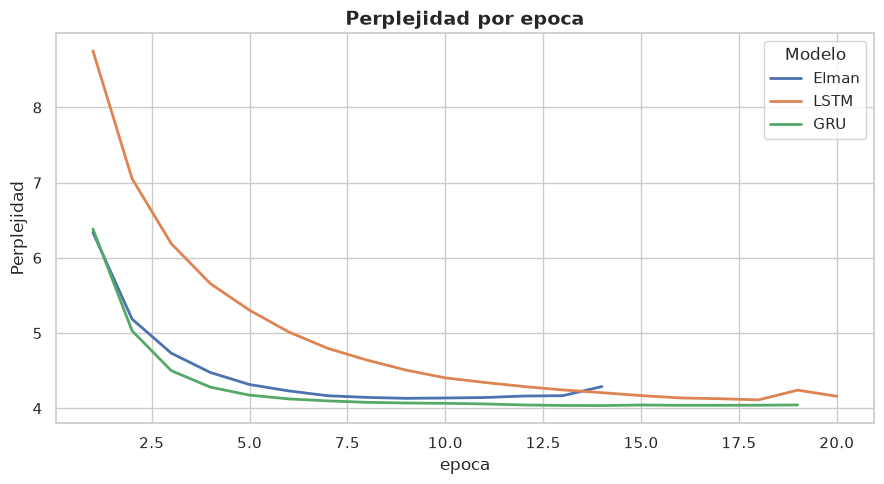

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

if len(elman_ppl) > 0:
    sns.lineplot(x=range(1, len(elman_ppl) + 1), y=elman_ppl, label="Elman", linewidth=2)

if len(lstm_ppl) > 0:
    sns.lineplot(x=range(1, len(lstm_ppl) + 1), y=lstm_ppl, label="LSTM", linewidth=2)

if len(gru_ppl) > 0:
    sns.lineplot(x=range(1, len(gru_ppl) + 1), y=gru_ppl, label="GRU", linewidth=2)

plt.title("Perplejidad por epoca", fontsize=14, weight="bold")
plt.xlabel("epoca", fontsize=12)
plt.ylabel("Perplejidad", fontsize=12)
plt.legend(title="Modelo", frameon=True)
plt.tight_layout()

plt.show()


### Comparación de Perplejidad

* **GRU**
  * Converge más rápido que las demás.
  * Logra la menor perplejidad y con mayor estabilidad.

* **Elman**
  * Arranca a la par de GRU gracias a tener más neuronas (128).
  * Se estanca y empieza a sobreajustar.
  
* **LSTM**
  * Converge mas lento.
  * Llega a un valor de perplejidad similar a GRU.

**Conclusion:** GRU es la arquitectura más eficiente para este tamaño de modelo y problema a nivel caracter al tener menor perplejidad y converger mas rapido.


In [31]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('best_gru.keras')


### Predicción del próximo caracter

In [32]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

/home/nacho/Documents/CEIA/procesamiento_lenguaje_natural/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Keyboard interruption in main thread... closing server.


### Generación de secuencias

In [33]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

###  Beam search y muestreo aleatorio

In [34]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [35]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]


### Analisis de secuencias

Se propone evaluar las secuencias
`El deseo de Gregorio de ver a la madre pronto se convirtió en realidad.` Es una frase extraida del corpus, nos permite ver la diferencia entre la original y la generada

`No siempre es la mejor idea seleccionar ` Es una frase que acota la respuesta del modelo y permite observa el efecto de la temperatura

`Cuando ` Es una frase corta y poco sugestiva que permite ver si el modelo logra armar algo coherente

Cada secuencia se generara con Greedy Search, Beam Search Deterministico, Beam Search estocastico con temperatura 0.7 y temperatura 1

Utilizamos el modelo que mejor perplejidad obtuvo


In [40]:
sequences = [
    'El deseo de Gregorio de ver a la madre pronto se convirtió en realidad.'.lower(),
    'No siempre es la mejor idea seleccionar '.lower(),
    'Cuando '.lower()
]
output_tokens = 50

In [42]:
for seq in sequences:
    print('-'*10, seq, '-'*10)
    print('greedy:')
    print(decode(beam_search(model,num_beams=1,num_words=output_tokens,input=seq)[0]))
    print('beam deterministico:')
    print(decode(beam_search(model,num_beams=10,num_words=output_tokens,input=seq)[0]))
    print('beam estocastico 0.7:')
    print(decode(beam_search(model,num_beams=10,num_words=output_tokens,input=seq,mode='sto',temp=0.7)[0]))
    print('beam estocastico 1:')
    print(decode(beam_search(model,num_beams=10,num_words=output_tokens,input=seq,mode='sto',temp=1)[0]))

---------- el deseo de gregorio de ver a la madre pronto se convirtió en realidad. ----------
greedy:
el deseo de gregorio de ver a la madre pronto se convirtió en realidad. el padre se alrededor de la cabeza de la cabeza d
beam deterministico:
el deseo de gregorio de ver a la madre pronto se convirtió en realidad. pero en la cabeza de la habitación de la hermana 
beam estocastico 0.7:
el deseo de gregorio de ver a la madre pronto se convirtió en realidad. estaba la hermana, porque estaba con la madre y l
beam estocastico 1:
el deseo de gregorio de ver a la madre pronto se convirtió en realidad. pero la hermana, pero gregorio no se había sido m
---------- no siempre es la mejor idea seleccionar  ----------
greedy:
no siempre es la mejor idea seleccionar a la cama y la hermana podía conseguido en la cama
beam deterministico:
no siempre es la mejor idea seleccionar la habitación de la habitación de la habitación de
beam estocastico 0.7:
no siempre es la mejor idea seleccionar a la madre 

### Conclusiones

| Metodo | Observacion |
| :--- | :--- |
| **Greedy Search ($k=1$)** | Cae en bucles locales (*"de la cabeza de la cabeza"*, *"en la cama ... en la cama"*). |
| **Beam Search Determinístico ($k=10$)** | Cae en bucle locales (*"la habitación de la habitación de la habitación de")*. |
| **Beam Search Estocástico ($T=0.7$)** | Oraciones fluidas con conectores (*"porque estaba con la madre"*, *"como si se..."*) e incluso logra cerrar oraciones con puntuación final (*"había continuado."*). |
| **Beam Search Estocástico ($T=1.0$)** | Mayor diversidad y estructuras complejas (*"a la hermana que la madre, porque el padre..."*), pero con repeticiones (*"pero la hermana, pero gregorio..."*). |


* **Aprendizaje a nivel caracter:** El modelo aprendió con éxito la morfología del español debido a que se observa separación correcta de palabras, tildes y estructuras gramaticales, sin haber sido entrenado con un diccionario de palabras.
* **Coherencia local vs. global:** A nivel local (palabras y frases cortas) la construcción es sólida; a nivel global el texto pierde hilo, quiza por la capacidad limitada de una red pequeña.
* **Sesgo del corpus:** La generación está fuertemente influenciada por las palabras de *La Metamorfosis* de Kafka (*Gregorio, padre, madre, hermana, habitación, cama, puerta*).

